# 18_AdaBoost

# AdaBoost

Random Forest는 여러 Decision Trees를 만들고 그 Prediction을 결합하였다.

이번에는 여러 Models을 순차적으로 Training하는 방법을 사용한다.

AdaBoost의 기본 아이디어는 다음과 같다.

> 앞의 Model이 잘못 Classification한 Data에 더 주목하여 다음 Model을 Training한다.

이 과정을 반복하면서 여러 Weak Models의 Prediction을 결합한다.

AdaBoost는 Adaptive Boosting의 줄임말이다.

## From Random Forest to Boosting

Random Forest에서는 여러 Trees를 만들어 그 결과를 결합한다.

AdaBoost에서도 여러 Models을 사용하지만 Training 방법이 다르다.

Random Forest:

> 여러 Trees를 만들고 Prediction을 결합

AdaBoost:

> Model을 순차적으로 만들면서 이전 Model의 Mistakes에 더 주목

따라서 AdaBoost에서는 앞에서 만들어진 Model의 결과가 다음 Model의 Training에 영향을 준다.

## Basic Idea

첫 번째 Model이 다음과 같이 일부 Data를 잘못 Classification했다고 하자.

$$
Model_1 \rightarrow \text{Some Wrong Predictions}
$$

다음 Model은 잘못 Classification된 Samples에 더 주목한다.

$$
Model_2 \rightarrow \text{Focus More on Previous Mistakes}
$$

이 과정을 반복한다.

$$
Model_1
\rightarrow
Model_2
\rightarrow
Model_3
\rightarrow
\cdots
$$

마지막에는 여러 Models의 Prediction을 결합하여 최종 Class를 결정한다.

## Weak Learner

AdaBoost에서는 각각의 Model이 매우 복잡할 필요가 없다.

일반적으로 간단한 Decision Tree를 Weak Learner로 사용할 수 있다.

특히 Depth가 1인 Decision Tree를 Decision Stump라고 한다.

Decision Stump는 하나의 Rule만을 이용하여 Data를 나누는 매우 단순한 Model이다.

AdaBoost는 이러한 Weak Learners를 여러 개 결합하여 더 강한 Model을 만든다.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Test Data:", X_test.shape)

Training Data: (120, 4)
Test Data: (30, 4)


## A Single Weak Learner

먼저 Depth가 1인 Decision Tree 하나만 사용하여 Classification해 보자.

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

stump = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

stump.fit(
    X_train,
    y_train
)

y_pred = stump.predict(
    X_test
)

stump_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Decision Stump Accuracy:",
    f"{stump_accuracy:.3f}"
)

Decision Stump Accuracy: 0.633


## AdaBoost

이제 여러 Weak Learners를 AdaBoost로 결합한다.

`n_estimators`는 순차적으로 사용할 Weak Learners의 수를 의미한다.

In [4]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

ada.fit(
    X_train,
    y_train
)

y_pred = ada.predict(
    X_test
)

ada_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "AdaBoost Accuracy:",
    f"{ada_accuracy:.3f}"
)

AdaBoost Accuracy: 0.933


## How Is the Weak Learner Determined?

AdaBoost에서는 먼저 사용할 Weak Learner의 기본 골격을 결정한다.

예를 들어 Decision Tree를 사용하고 `max_depth=1`로 설정하면 모든 Weak Learners는 동일한 구조의 Decision Stump를 사용한다.

이러한 Model의 종류와 구조는 사용자가 결정하는 Hyperparameter이다.

그러나 각각의 Weak Learner가 사용하는 구체적인 Classification Rule은 Training 과정에서 Data로부터 결정된다.

첫 번째 Weak Learner는 모든 Training Samples에 동일한 Weight를 주고 학습한다.

> Weak Learner 1 → Wrong Samples 발견 → Sample Weights 변경

다음 Weak Learner는 같은 Training Data를 사용하지만 변경된 Sample Weights를 이용하여 다시 학습한다.

> Weak Learner 2 → Wrong Samples 발견 → Sample Weights 변경

이 과정을 반복한다.

따라서 AdaBoost에서는

- Weak Learner의 기본 골격은 동일하다.
- Training Data도 동일하다.
- 각 단계에서 Sample Weights가 달라진다.
- Sample Weights가 달라지므로 각 Weak Learner가 학습하는 Classification Rule도 달라질 수 있다.

즉,

> Same Weak Learner Structure + Different Sample Weights → Different Classification Rules

이것이 AdaBoost가 여러 Weak Learners를 순차적으로 만드는 기본 원리이다.

## How to Choose the Next Weak Learner?

AdaBoost는 이전 Weak Learner가 잘못 Classification한 Samples의 Weight를 증가시킨다.

다음 Weak Learner는 변경된 Sample Weights를 이용하여 새롭게 Training된다.

따라서 다음 Weak Learner는 이전에 잘못 Classification된 Samples를 더 중요하게 고려하여 Classification Rule을 결정한다.

Weak Learner 1
Decision Stump + 동일한 Sample Weight
        ↓
틀린 Sample의 Weight 증가
        ↓
Weak Learner 2
Decision Stump + 변경된 Sample Weight
        ↓
틀린 Sample의 Weight 증가
        ↓
Weak Learner 3
Decision Stump + 다시 변경된 Sample Weight

## Single Tree vs AdaBoost

하나의 Weak Learner와 여러 Weak Learners를 결합한 AdaBoost의 결과를 비교해 보자.

In [5]:
print(
    "Decision Stump:",
    f"{stump_accuracy:.3f}"
)

print(
    "AdaBoost:",
    f"{ada_accuracy:.3f}"
)

Decision Stump: 0.633
AdaBoost: 0.933


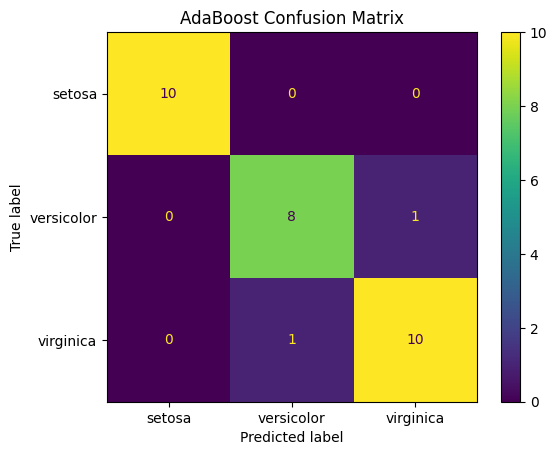

In [6]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
).plot()

plt.title("AdaBoost Confusion Matrix")
plt.show()

## Number of Estimators

`n_estimators`는 AdaBoost가 순차적으로 사용하는 Weak Learners의 최대 수를 지정한다.

Estimator 수를 변경하면서 Classification Performance를 비교해 보자.

In [7]:
estimator_numbers = [
    1,
    5,
    10,
    20,
    50,
    100
]

for n in estimator_numbers:

    model = AdaBoostClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    accuracy = model.score(
        X_test,
        y_test
    )

    print(
        f"Estimators={n}, "
        f"Accuracy={accuracy:.3f}"
    )

Estimators=1, Accuracy=0.633
Estimators=5, Accuracy=1.000
Estimators=10, Accuracy=1.000
Estimators=20, Accuracy=1.000
Estimators=50, Accuracy=0.933
Estimators=100, Accuracy=0.933


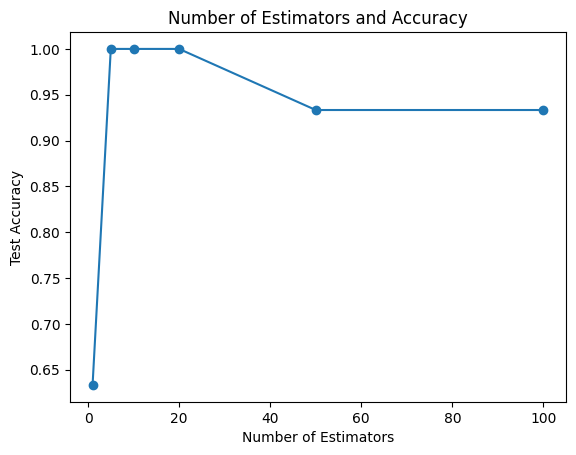

In [8]:
accuracies = []

for n in estimator_numbers:

    model = AdaBoostClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    accuracies.append(
        model.score(
            X_test,
            y_test
        )
    )

plt.plot(
    estimator_numbers,
    accuracies,
    marker="o"
)

plt.xlabel("Number of Estimators")
plt.ylabel("Test Accuracy")
plt.title("Number of Estimators and Accuracy")

plt.show()

## Random Forest vs AdaBoost

Random Forest와 AdaBoost는 모두 여러 Trees를 이용할 수 있다.

그러나 Trees를 만드는 방법이 다르다.

Random Forest:

> 여러 Trees를 만들고 그 Prediction을 결합한다.

AdaBoost:

> Models을 순차적으로 Training하며 이전 Model이 틀린 Samples에 더 주목한다.

Random Forest의 핵심은 여러 Trees의 다양한 판단을 결합하는 것이고,

AdaBoost의 핵심은 이전 Mistakes를 다음 Model이 보완하도록 하는 것이다.

## Summary

AdaBoost는 여러 Weak Learners를 순차적으로 결합하는 Ensemble Method이다.

기본 과정은 다음과 같다.

> Weak Model → Mistakes → Focus on Mistakes → Next Model → Combine Models

핵심 사항:

- 여러 Weak Learners를 사용한다.
- Models을 순차적으로 Training한다.
- 이전 Model이 잘못 Classification한 Samples에 더 주목한다.
- 간단한 Decision Tree를 Weak Learner로 사용할 수 있다.
- `n_estimators`를 이용하여 Estimator의 수를 조절할 수 있다.

## Homework - Problem 18

Iris Dataset의 4개 Features를 모두 사용하여 AdaBoost를 학습한다.

다음 조건을 사용한다.

- `test_size=0.2`
- `random_state=42`
- `n_estimators = 5, 10, 50, 100`

다음 질문에 답하시오.

- 각 `n_estimators`의 Test Accuracy를 소수점 셋째 자리까지 적으시오.
- 가장 높은 Test Accuracy를 보인 `n_estimators`를 모두 적으시오.

답만 제출하시오.